<a href="https://colab.research.google.com/github/SyedAzeeemAli/AI_ML-Assesment-Project/blob/main/Spotter_Freight_Rate_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spotter Freight Rate Prediction**

## **Objective**
Build a machine learning model using historical freight load data to predict freight rates for unseen loads.

## **Workflow**
1. Data loading and inspection
2. Exploratory data analysis
3. Data quality checks
4. Feature engineering
5. Time-based train/validation split
6. Baseline and model comparison
7. Final model training
8. Validation set predictions
9. December 2025 predictions
10. Final scoring and submission files

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## **Data loading and inspection**

In [2]:
# Loading Data

train_df = pd.read_csv("/content/drive/MyDrive/assesment_test_data/train-test.csv")
validation_df = pd.read_csv("/content/drive/MyDrive/assesment_test_data/validation.csv")
pred_template = pd.read_csv("/content/drive/MyDrive/assesment_test_data/validation-predictions-template.csv")
december_df = pd.read_csv("/content/drive/MyDrive/assesment_test_data/december-chart-inputs.csv")

In [3]:
# Checking properties of the dataset

print("Train shape:", train_df.shape)
print("Final validation shape:", validation_df.shape)
print("Prediction template shape:", pred_template.shape)
print("December shape:", december_df.shape)

Train shape: (48000, 14)
Final validation shape: (12000, 13)
Prediction template shape: (12000, 2)
December shape: (31, 7)


In [4]:
train_df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
# All the columns on the Dataset

train_df.columns.to_list()

['load_id',
 'pickup',
 'delivery',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'equipment',
 'weight',
 'date',
 'market_index',
 'quote_signal',
 'posted_rate']

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


**Note for Myself: Target Variable**

The target variable is `posted_rate`, representing the historical freight rate for each load.

In [7]:
train_df["posted_rate"].describe()

,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


In [8]:
# Target variable in both datasets
print("Training columns:")
print(train_df.columns.tolist())

print("\nFinal validation columns:")
print(validation_df.columns.tolist())

print("\nTarget in train:",
      "posted_rate" in train_df.columns)

print("Target in final validation:",
      "posted_rate" in validation_df.columns)

Training columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Final validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

Target in train: True
Target in final validation: False


In [9]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
market_index,374
weight,300


In [10]:
validation_missing = (
    validation_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

validation_missing[validation_missing > 0]

,0
market_index,249
weight,165


**Training Data missing values:**

*market_index: 374, weight:300*






**Validation Data missing values:**

*market_index: 249, weight:165*

## **Exploratory Data Analysis**

The goal of this section is to understand the target distribution, categorical features, numerical relationships, temporal patterns, and potential data-quality issues before model development.

In [11]:
# Checking out the duplicate values in training dataset

print("Duplicate rows: ", train_df.duplicated().sum())
print("Duplicate load ids", train_df["load_id"].duplicated().sum())

Duplicate rows:  0
Duplicate load ids 0


In [12]:
# Understanding categorical columns

categorical_cols = ["pickup", "delivery", "equipment"]
for col in categorical_cols:
    print(f"\n{col.upper()}")
    print("Unique values:", train_df[col].nunique())
    print(train_df[col].value_counts().head(10))


PICKUP
Unique values: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Name: count, dtype: int64

DELIVERY
Unique values: 64
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Name: count, dtype: int64

EQUIPMENT
Unique values: 3
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


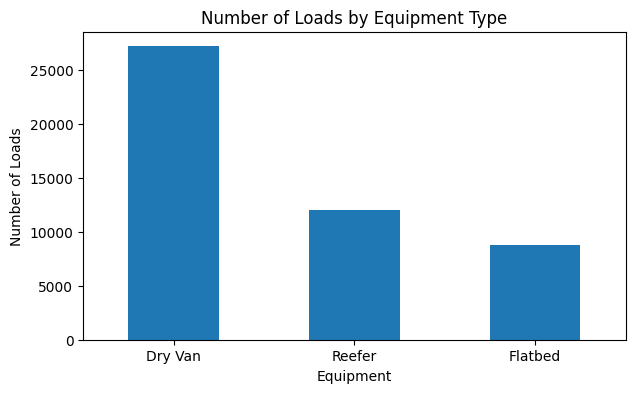

In [13]:
# Inspecting visually 'EQUIPMENT' column
equipment_counts = train_df["equipment"].value_counts()

equipment_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Number of Loads by Equipment Type")
plt.xlabel("Equipment")
plt.ylabel("Number of Loads")
plt.xticks(rotation=0)
plt.show()

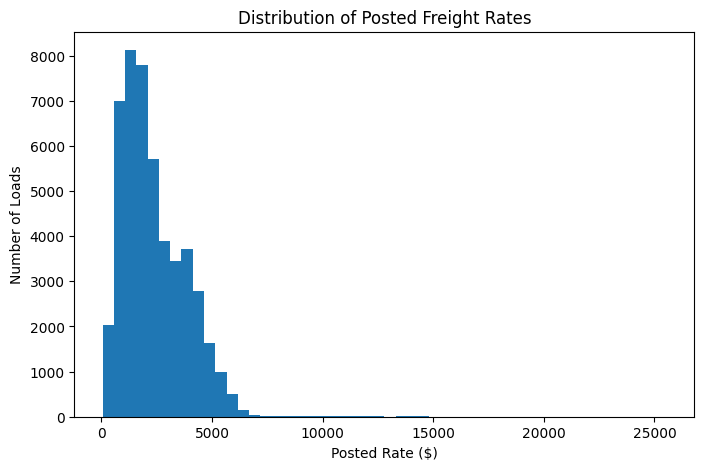

In [14]:
# Inspecting visually 'posted_rate' (target) column
plt.figure(figsize=(8, 5))

plt.hist(
    train_df["posted_rate"],
    bins=50
)

plt.title("Distribution of Posted Freight Rates")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")
plt.show()

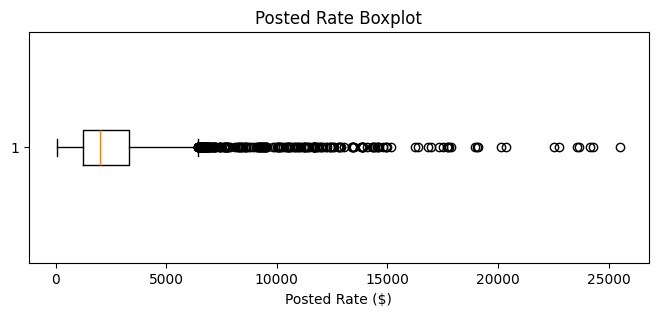

In [15]:
plt.figure(figsize=(8, 3))

plt.boxplot(
    train_df["posted_rate"],
    vert=False
)

plt.title("Posted Rate Boxplot")
plt.xlabel("Posted Rate ($)")
plt.show()

In [16]:
# loading the most expensive loads

train_df.nlargest(
    10,
    "posted_rate"
)[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
]

,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate
12184,Bakersfield,Hartford,2829.8,Dry Van,33153.0,2025-03-19,1.16556,1.83188,25533.00
37764,Phoenix,Syracuse,2810.9,Dry Van,33674.0,2025-08-27,1.04877,2.16284,24294.98
1466,Los Angeles,Syracuse,2786.0,Reefer,30322.0,2025-01-10,0.98678,1.85370,24140.21
17371,Reno,Philadelphia,2777.6,Reefer,33158.0,2025-04-20,1.15070,2.15601,23662.71
26235,Charleston,Phoenix,2552.5,Dry Van,25665.0,2025-06-15,1.20224,1.81289,23580.42
28219,Tucson,Raleigh,2423.3,Dry Van,30972.0,2025-06-27,1.32894,1.97112,22755.66
3353,Phoenix,Charleston,2527.9,Reefer,36840.0,2025-01-22,1.03241,2.07342,22534.65
40171,Montgomery,Fresno,2283.4,Dry Van,32447.0,2025-09-11,0.98502,1.93645,20361.89
40096,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,2025-09-11,1.00464,2.28753,20132.37
47298,Boston,Bakersfield,2979.1,Reefer,30585.0,2025-10-27,0.86501,2.09472,19110.30


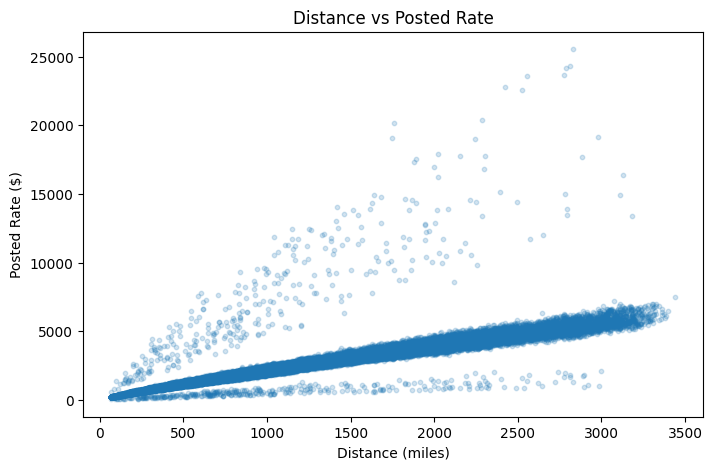

In [17]:
# Plotting Distance vs posted rate
plt.figure(figsize=(8, 5))

plt.scatter(
    train_df["distance"],
    train_df["posted_rate"],
    alpha=0.2,
    s=10
)

plt.title("Distance vs Posted Rate")
plt.xlabel("Distance (miles)")
plt.ylabel("Posted Rate ($)")
plt.show()

In [18]:
# checking the correlation between them

distance_corr = train_df["distance"].corr(
    train_df["posted_rate"]
)

print("Distance vs posted rate correlation:", distance_corr)

Distance vs posted rate correlation: 0.9085191518300778


**Note for myself: Strong relation between them**

In [19]:
# rate according to equipment

train_df.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
equipment,,,
Reefer,12045,2553.636939,2196.670
Flatbed,8753,2445.087223,2076.810
Dry Van,27202,2271.548686,1953.035


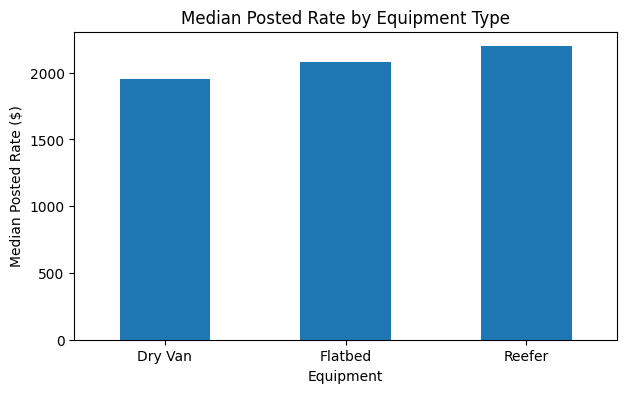

In [20]:
equipment_rate = (
    train_df
    .groupby("equipment")["posted_rate"]
    .median()
    .sort_values()
)

equipment_rate.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Median Posted Rate by Equipment Type")
plt.xlabel("Equipment")
plt.ylabel("Median Posted Rate ($)")
plt.xticks(rotation=0)
plt.show()

In [21]:
# Quick overview of relation between all numerical and target columns
numeric_cols = train_df.select_dtypes(
    include=np.number
).columns

correlations = (
    train_df[numeric_cols]
    .corr()["posted_rate"]
    .sort_values(ascending=False)
)

correlations

,posted_rate
posted_rate,1.000000
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858
pickup_lat,-0.090873
delivery_lat,-0.091970
pickup_lon,-0.255058
delivery_lon,-0.257086


Now check the rate according to months

In [22]:
# Convert the date column to datetime and then extract the month
train_df["date"] = pd.to_datetime(train_df["date"])
train_df["month"] = train_df["date"].dt.month

In [23]:
monthly_rates = (
    train_df
    .groupby("month")["posted_rate"]
    .agg(["mean", "median", "count"])
)

monthly_rates

,mean,median,count
month,,,
1,2255.967048,1915.200,4918
2,2273.804801,1994.250,4337
3,2372.268092,2022.920,5036
4,2372.162308,2044.240,4819
5,2421.776342,2065.510,4913
6,2497.030115,2120.220,4783
7,2415.162030,2059.145,4912
8,2338.407661,2015.730,4759
9,2406.374013,2057.130,4670


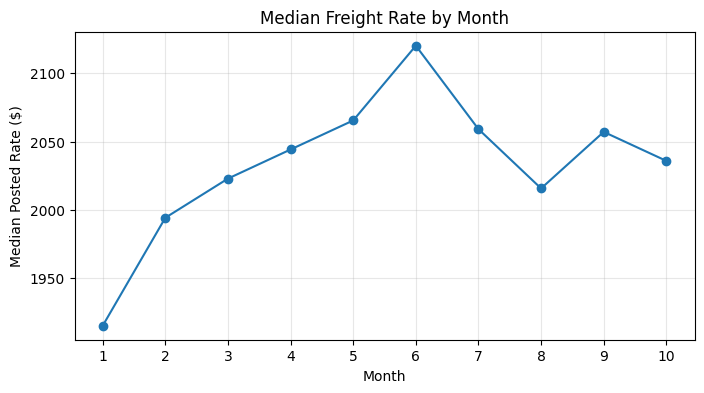

In [24]:
monthly_rates["median"].plot(
    marker="o",
    figsize=(8, 4)
)

plt.title("Median Freight Rate by Month")
plt.xlabel("Month")
plt.ylabel("Median Posted Rate ($)")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

In [25]:
# Training vs Final Validation categories

for col in ["pickup", "delivery", "equipment"]:
    train_values = set(train_df[col].dropna())
    final_values = set(validation_df[col].dropna())

    unseen = final_values - train_values

    print(f"{col}:")
    print("  Train unique:", len(train_values))
    print("  Final validation unique:", len(final_values))
    print("  Unseen in training:", unseen)
    print()

pickup:
  Train unique: 64
  Final validation unique: 72
  Unseen in training: {'Jackson', 'Knoxville', 'San Diego', 'Allentown', 'Norfolk', 'Chicago', 'Laredo', 'Charlotte'}

delivery:
  Train unique: 64
  Final validation unique: 72
  Unseen in training: {'Jackson', 'Knoxville', 'San Diego', 'Allentown', 'Norfolk', 'Chicago', 'Laredo', 'Charlotte'}

equipment:
  Train unique: 3
  Final validation unique: 3
  Unseen in training: set()



In [26]:
# Finding the relation between posted_rate and distance

train_df["rate_per_mile"] = (
    train_df["posted_rate"] / train_df["distance"]
)

train_df["rate_per_mile"].describe()

,rate_per_mile
count,48000.000000
mean,2.215347
std,0.583887
min,0.333709
25%,1.986974
50%,2.145348
75%,2.342696
max,14.125294


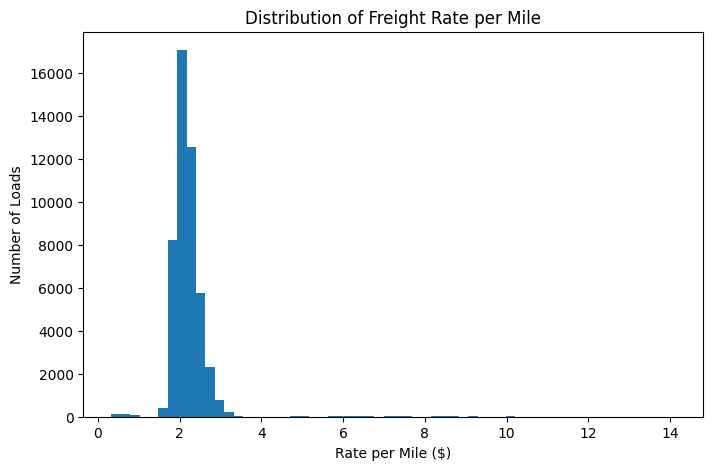

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_df["rate_per_mile"],
    bins=60
)

plt.title("Distribution of Freight Rate per Mile")
plt.xlabel("Rate per Mile ($)")
plt.ylabel("Number of Loads")
plt.show()

In [28]:
# Highest rate-per-mile loads
train_df.nlargest(
    20,
    "rate_per_mile"
)[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "market_index",
        "quote_signal",
        "posted_rate",
        "rate_per_mile"
    ]
]

,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate,rate_per_mile
22254,Greensboro,Cincinnati,314.7,Reefer,-36485.0,2025-05-21,1.37257,1.24215,4445.23,14.125294
36609,Chattanooga,Atlanta,98.4,Reefer,22226.0,2025-08-20,1.03474,2.58457,1386.42,14.089634
870,Tulsa,Baton Rouge,305.6,Reefer,26447.0,2025-01-06,0.80857,2.64181,4069.24,13.315576
17070,Toledo,Dayton,201.5,Flatbed,38714.0,2025-04-18,1.30277,1.44259,2609.34,12.949578
27969,Buffalo,Boston,589.9,Reefer,24951.0,2025-06-25,1.33920,2.58804,7597.52,12.879335
23369,Amarillo,Lubbock,412.4,Flatbed,35494.0,2025-05-28,1.38576,1.40576,5308.96,12.873327
28012,Montgomery,Houston,604.3,Reefer,39690.0,2025-06-25,1.31135,2.76111,7773.37,12.863429
45483,Greensboro,Columbia,153.8,Dry Van,34198.0,2025-10-15,1.00256,1.46388,1971.21,12.816710
1415,Montgomery,Birmingham,198.2,Reefer,25383.0,2025-01-09,0.99663,2.66449,2509.96,12.663774
21968,Jacksonville,Columbia,254.5,Dry Van,32993.0,2025-05-19,1.21285,1.52868,3220.66,12.654853


In [29]:
# Checking all the invalid weights in training dataset

invalid_weights = train_df[
    (train_df["weight"] <= 0) |
    (train_df["weight"].isna())
]

print("Missing/invalid weights:", len(invalid_weights))
print("Negative weights:", (train_df["weight"] < 0).sum())
print("Zero weights:", (train_df["weight"] == 0).sum())

invalid_weights[
    ["load_id", "weight", "distance", "posted_rate"]
].head(20)

Missing/invalid weights: 592
Negative weights: 292
Zero weights: 0


,load_id,weight,distance,posted_rate
68,TR-000069,-36559.0,1334.2,2831.27
204,TR-000205,-26670.0,496.2,1046.92
206,TR-000207,-20003.0,411.3,959.15
225,TR-000226,-23981.0,1317.4,2836.00
323,TR-000324,NaN,2848.8,5430.07
376,TR-000377,-41397.0,1331.1,2522.54
446,TR-000447,-37215.0,2438.3,4841.57
495,TR-000496,-31214.0,715.9,1473.78
641,TR-000642,-41023.0,582.4,1264.33
648,TR-000649,NaN,467.0,1178.03


In [30]:
# Checking invalid wights in validation dataset
print(
    "Final validation negative weights:",
    (validation_df["weight"] < 0).sum()
)

print(
    "Final validation missing weights:",
    validation_df["weight"].isna().sum()
)

Final validation negative weights: 145
Final validation missing weights: 165


Checking out hidden nonlinear effect of quote_signal

In [31]:
pd.qcut(
    train_df["quote_signal"],
    q=10,
    duplicates="drop"
)

,quote_signal
0,"(2.266, 2.403]"
1,"(2.403, 3.61]"
2,"(1.735, 1.851]"
3,"(1.851, 1.928]"
4,"(2.403, 3.61]"
...,...
47995,"(2.056, 2.118]"
47996,"(0.691, 1.735]"
47997,"(0.691, 1.735]"
47998,"(1.994, 2.056]"


In [32]:
train_df["quote_signal_bin"] = pd.qcut(
    train_df["quote_signal"],
    q=10,
    duplicates="drop"
)

quote_analysis = (
    train_df
    .groupby(
        "quote_signal_bin",
        observed=True
    )
    .agg(
        count=("posted_rate", "size"),
        median_rate=("posted_rate", "median"),
        median_rate_per_mile=("rate_per_mile", "median")
    )
)

quote_analysis

,count,median_rate,median_rate_per_mile
quote_signal_bin,,,
"(0.691, 1.735]",4800,1038.495,2.529416
"(1.735, 1.851]",4801,2304.070,2.277579
"(1.851, 1.928]",4799,2430.050,2.031208
"(1.928, 1.994]",4800,2297.865,2.009317
"(1.994, 2.056]",4803,2297.590,2.068177
"(2.056, 2.118]",4797,2270.130,2.077862
"(2.118, 2.185]",4800,2353.040,2.105448
"(2.185, 2.266]",4800,2401.185,2.182706
"(2.266, 2.403]",4800,2051.335,2.292560


In [33]:
# Same test with market index

train_df["market_bin"] = pd.qcut(
    train_df["market_index"],
    q=10,
    duplicates="drop"
)

market_analysis = (
    train_df
    .groupby(
        "market_bin",
        observed=True
    )
    .agg(
        count=("posted_rate", "size"),
        median_rate=("posted_rate", "median"),
        median_rate_per_mile=("rate_per_mile", "median")
    )
)

market_analysis

,count,median_rate,median_rate_per_mile
market_bin,,,
"(0.675, 0.871]",4763,2010.310,2.092226
"(0.871, 0.926]",4763,1968.030,2.097668
"(0.926, 0.971]",4763,2006.150,2.091168
"(0.971, 1.013]",4763,1981.820,2.111514
"(1.013, 1.056]",4763,1990.730,2.126437
"(1.056, 1.121]",4762,2024.005,2.132020
"(1.121, 1.193]",4761,2067.470,2.160816
"(1.193, 1.253]",4763,2090.560,2.188052
"(1.253, 1.333]",4762,2070.180,2.213282


In [34]:
# Month analysis

train_df["month"] = train_df["date"].dt.month

monthly_analysis = (
    train_df
    .groupby("month")
    .agg(
        loads=("posted_rate", "size"),
        mean_rate=("posted_rate", "mean"),
        median_rate=("posted_rate", "median"),
        median_rate_per_mile=("rate_per_mile", "median")
    )
)

monthly_analysis

,loads,mean_rate,median_rate,median_rate_per_mile
month,,,,
1,4918,2255.967048,1915.200,2.029158
2,4337,2273.804801,1994.250,2.061143
3,5036,2372.268092,2022.920,2.139279
4,4819,2372.162308,2044.240,2.146699
5,4913,2421.776342,2065.510,2.190194
6,4783,2497.030115,2120.220,2.247885
7,4912,2415.162030,2059.145,2.187422
8,4759,2338.407661,2015.730,2.120525
9,4670,2406.374013,2057.130,2.159622


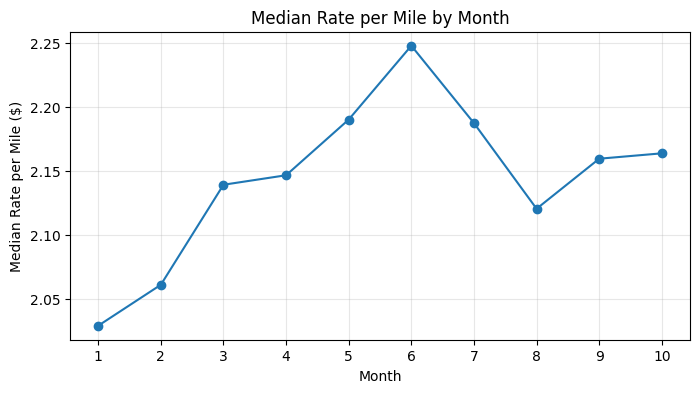

In [35]:
plt.figure(figsize=(8, 4))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["median_rate_per_mile"],
    marker="o"
)

plt.title("Median Rate per Mile by Month")
plt.xlabel("Month")
plt.ylabel("Median Rate per Mile ($)")
plt.xticks(monthly_analysis.index)
plt.grid(alpha=0.3)
plt.show()

In [36]:
# Unseen cities check

for col in ["pickup", "delivery", "equipment"]:
    train_values = set(train_df[col].dropna())
    final_values = set(validation_df[col].dropna())

    unseen = final_values - train_values

    print(f"{col}:")
    print("Train unique:", len(train_values))
    print("Final validation unique:", len(final_values))
    print("Unseen values:", unseen)
    print()

pickup:
Train unique: 64
Final validation unique: 72
Unseen values: {'Jackson', 'Knoxville', 'San Diego', 'Allentown', 'Norfolk', 'Chicago', 'Laredo', 'Charlotte'}

delivery:
Train unique: 64
Final validation unique: 72
Unseen values: {'Jackson', 'Knoxville', 'San Diego', 'Allentown', 'Norfolk', 'Chicago', 'Laredo', 'Charlotte'}

equipment:
Train unique: 3
Final validation unique: 3
Unseen values: set()



In [37]:
# Checking invalid numeric values

numeric_checks = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

for col in numeric_checks:
    print(
        col,
        "| missing:", train_df[col].isna().sum(),
        "| <= 0:", (train_df[col] <= 0).sum()
    )

distance | missing: 0 | <= 0: 0
weight | missing: 300 | <= 0: 292
market_index | missing: 374 | <= 0: 0
quote_signal | missing: 0 | <= 0: 0
posted_rate | missing: 0 | <= 0: 0


## **Data Preparation and Validation Strategy**

Since the final evaluation data represents future loads, a time-based validation strategy is used instead of a random split.

Loads before October 2025 are used for development training, while October 2025 is held out as a simulated future validation period.

In [38]:
# Reload the original dataset to create a clean dataframe for modelling.
# This removes temporary columns that were created only for EDA.

model_df = pd.read_csv("/content/drive/MyDrive/assesment_test_data/train-test.csv")


# Convert the date column to datetime so we can create time-based features
# and perform a chronological train validation split.
model_df["date"] = pd.to_datetime(model_df["date"])

In [39]:
# Freight weight cannot be negative, so negative values are treated as missing.
# We do not convert them to positive values because we cannot assume
# that the negative sign is simply a data-entry error.

model_df.loc[
    model_df["weight"] <= 0,
    "weight"
] = np.nan

print("Negative weights:", (model_df["weight"] < 0).sum())
print("Missing weights:", model_df["weight"].isna().sum())

Negative weights: 0
Missing weights: 592


In [40]:
# Extract useful calendar features from the raw date.
# These features allow the model to learn seasonal and weekly pricing patterns

model_df["month"] = model_df["date"].dt.month
model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["day_of_month"] = model_df["date"].dt.day

Time-based split of Training data into dev_train & dev_val

In [41]:
# Use a time-based split because the final evaluation set contains future dates.
# We train on January–September and hold out October to simulate
# how the model will perform when predicting future freight rates.

dev_train = model_df[
    model_df["date"] < "2025-10-01"
].copy()

dev_val = model_df[
    model_df["date"] >= "2025-10-01"
].copy()

print("Development train:", dev_train.shape)
print("Development validation:", dev_val.shape)

print(
    "Train dates:",
    dev_train["date"].min(),
    "→",
    dev_train["date"].max()
)

print(
    "Validation dates:",
    dev_val["date"].min(),
    "→",
    dev_val["date"].max()
)

Development train: (43147, 17)
Development validation: (4853, 17)
Train dates: 2025-01-01 00:00:00 → 2025-09-30 00:00:00
Validation dates: 2025-10-01 00:00:00 → 2025-10-31 00:00:00


In [42]:
# Splitting into x and y

target = "posted_rate"

X_train = dev_train.drop(columns=[target])
y_train = dev_train[target]

X_val = dev_val.drop(columns=[target])
y_val = dev_val[target]

In [43]:
# Removing load_id because it is only a unique identifier and does not
# represent meaningful pricing information.

drop_cols = ["load_id", "date"]

X_train = X_train.drop(columns=drop_cols)
X_val = X_val.drop(columns=drop_cols)

In [44]:
X_train.columns.tolist()

['pickup',
 'delivery',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'equipment',
 'weight',
 'market_index',
 'quote_signal',
 'month',
 'day_of_week',
 'day_of_month']

## **Modelling Experiments**

### **Model 1: Baseline Model**

In [45]:
# Build a simple freight-pricing baseline using the median rate per mile
# from the training period only.
# Using only training data prevents information from the validation period
# from leaking into the baseline.


train_rate_per_mile = (
    y_train / X_train["distance"]
)

baseline_rate_per_mile = train_rate_per_mile.median()

print(
    "Baseline rate per mile:",
    baseline_rate_per_mile
)

Baseline rate per mile: 2.142844129554656


In [46]:
# Predict each October load using the simple baseline

baseline_preds = (
    X_val["distance"] * baseline_rate_per_mile
)

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [48]:
baseline_mae = mean_absolute_error(
    y_val,
    baseline_preds
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        baseline_preds
    )
)

baseline_r2 = r2_score(
    y_val,
    baseline_preds
)

print(f"Baseline MAE:  ${baseline_mae:,.2f}")
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  $253.85
Baseline RMSE: $695.05
Baseline R²:   0.7932


### **Model 2: Random Forest Regressor**

I first train a Random Forest model as a machine learning benchmark and compare it against the simple rate-per-mile baseline using the same October holdout set.

**First, I need to preprocess the data for our Model**

In [49]:
# I separate categorical and numerical features so I can apply
# the appropriate preprocessing to each type.

categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day_of_week",
    "day_of_month"
]

In [50]:
# I use separate preprocessing pipelines for numeric and categorical features.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [51]:
# I impute missing numeric values with the median because it is robust
# to extreme values and is learned only from the training data.

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# I use one-hot encoding for categorical features and ignore unseen
# categories so new cities in future data do not cause prediction errors.

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [52]:
# Now Loading in the Model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [53]:
# I combine preprocessing and modelling into one pipeline so the same
# transformations are applied consistently during training and prediction.

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [54]:
# Now training the full pipeline using only the January–September development data.

rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['pickup_lat', 'pickup_lon',
                                                   'delivery_lat',
                                                   'delivery_lon', 'distance',
                                                   'weight', 'market_index',
                                                   'quote_signal', 'month',
                                                   'day_of_week',
                                                   'day_of_month']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['pickup', 'delivery',
                                                   'equipment'])])),
                ('model',
                 RandomForestRegressor(min_samples_leaf=2, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [55]:
# I predict the held-out October loads to measure performance on data that occurs after the training period.

rf_preds = rf_pipeline.predict(X_val)

In [56]:
# I evaluate Random Forest using the same metrics and October holdout
# used for the baseline so the comparison remains fair.

rf_mae = mean_absolute_error(
    y_val,
    rf_preds
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_preds
    )
)

rf_r2 = r2_score(
    y_val,
    rf_preds
)

print(f"Random Forest MAE:  ${rf_mae:,.2f}")
print(f"Random Forest RMSE: ${rf_rmse:,.2f}")
print(f"Random Forest R²:   {rf_r2:.4f}")

Random Forest MAE:  $147.76
Random Forest RMSE: $671.49
Random Forest R²:   0.8070


In [57]:
# I compare the first ML model against the simple freight-pricing baseline
# to verify whether the additional model complexity provides real improvement.

results = pd.DataFrame({
    "Model": [
        "Rate-per-Mile Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Rate-per-Mile Baseline,253.847949,695.04688,0.793241
1,Random Forest,147.760412,671.48510,0.807021


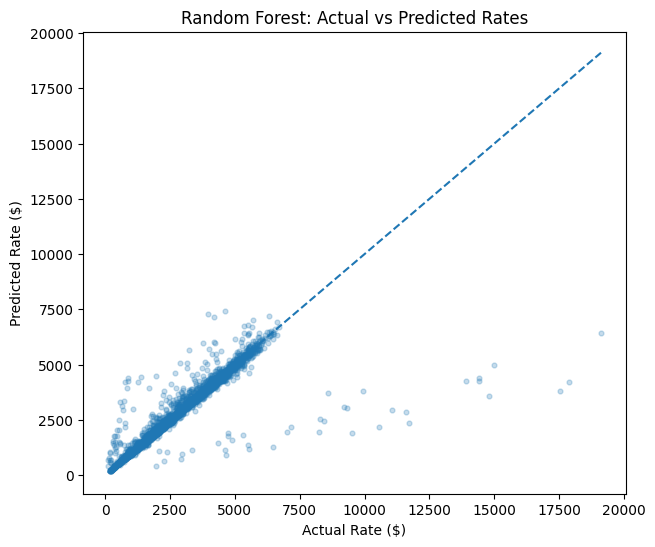

In [58]:
# I inspect actual versus predicted rates to see where the model
# performs well and where large prediction errors remain.

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    rf_preds,
    alpha=0.25,
    s=12
)

min_rate = min(y_val.min(), rf_preds.min())
max_rate = max(y_val.max(), rf_preds.max())

plt.plot(
    [min_rate, max_rate],
    [min_rate, max_rate],
    linestyle="--"
)

plt.xlabel("Actual Rate ($)")
plt.ylabel("Predicted Rate ($)")
plt.title("Random Forest: Actual vs Predicted Rates")
plt.show()

### **Model 3: CatBoost Model**

In [59]:
# I install CatBoost to test a stronger model that can directly
# handle categorical features and non-linear relationships.

!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [60]:
# I create separate copies for CatBoost so my previous
# Random Forest data and pipeline remain unchanged.

X_train_cb = dev_train.drop(
    columns=["posted_rate", "load_id", "date"]
).copy()

X_val_cb = dev_val.drop(
    columns=["posted_rate", "load_id", "date"]
).copy()

y_train_cb = dev_train["posted_rate"].copy()
y_val_cb = dev_val["posted_rate"].copy()

In [61]:
# I keep missing numeric values as NaN because CatBoost can handle them directly.
# And also convert categorical features to strings for consistent processing.

categorical_features_cb = [
    "pickup",
    "delivery",
    "equipment"
]

for col in categorical_features_cb:
    X_train_cb[col] = X_train_cb[col].fillna("Unknown").astype(str)
    X_val_cb[col] = X_val_cb[col].fillna("Unknown").astype(str)

In [62]:
# Now loading in the Model

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

In [63]:
# I train on January–September and use October only for validation.
# Early stopping keeps the best iteration when validation performance stops improving.

cat_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=categorical_features_cb,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=100,
    use_best_model=True
)

0:	learn: 1106.0570016	test: 1126.3575296	best: 1126.3575296 (0)	total: 168ms	remaining: 2m 47s
100:	learn: 110.7075961	test: 120.8675086	best: 120.8675086 (100)	total: 4.5s	remaining: 40.1s
200:	learn: 102.5823441	test: 113.7616256	best: 113.7616256 (200)	total: 7.26s	remaining: 28.9s
300:	learn: 100.3662252	test: 117.6445680	best: 113.3435316 (233)	total: 10.7s	remaining: 24.9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 113.3435316
bestIteration = 233

Shrink model to first 234 iterations.


CatBoostRegressor(depth=8, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [64]:
# generate predictions for the same October holdout

cat_preds = cat_model.predict(X_val_cb)

In [65]:
# I evaluate CatBoost using the same metrics.

cat_mae = mean_absolute_error(
    y_val_cb,
    cat_preds
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_val_cb,
        cat_preds
    )
)

cat_r2 = r2_score(
    y_val_cb,
    cat_preds
)

print(f"CatBoost MAE:  ${cat_mae:,.2f}")
print(f"CatBoost RMSE: ${cat_rmse:,.2f}")
print(f"CatBoost R²:   {cat_r2:.4f}")

CatBoost MAE:  $113.34
CatBoost RMSE: $645.82
CatBoost R²:   0.8215


In [66]:
# Compared all tested approaches on the same October holdout

results = pd.DataFrame({
    "Model": [
        "Rate-per-Mile Baseline",
        "Random Forest",
        "CatBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        cat_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        cat_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        cat_r2
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE,R2
2,CatBoost,113.343532,645.816357,0.821493
1,Random Forest,147.760412,671.485100,0.807021
0,Rate-per-Mile Baseline,253.847949,695.046880,0.793241


### **Final Model Training and Predictions**

Based on the time-based validation results, I selected CatBoost as the final model. I retrain it on all available labelled data before generating predictions for the unseen evaluation set.

In [67]:
# I prepare all 48,000 labelled records so the final model can learn
# from the complete historical dataset before predicting unseen loads.

final_train = model_df.copy()

X_full = final_train.drop(
    columns=["posted_rate", "load_id", "date"]
).copy()

y_full = final_train["posted_rate"].copy()

for col in categorical_features_cb:
    X_full[col] = X_full[col].fillna("Unknown").astype(str)

print("Final training shape:", X_full.shape)

Final training shape: (48000, 14)


In [68]:
# Reuse the number of iterations selected during validation
# and retrain CatBoost on the complete labelled dataset.

best_iterations = cat_model.get_best_iteration() + 1

print("Best iterations:", best_iterations)

Best iterations: 234


In [69]:
# I train the final model on all available labelled data using
# the model configuration that performed best during validation.

final_model = CatBoostRegressor(
    iterations=best_iterations,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

final_model.fit(
    X_full,
    y_full,
    cat_features=categorical_features_cb
)

0:	learn: 1428.5110038	total: 93.5ms	remaining: 21.8s
100:	learn: 584.1728423	total: 6.95s	remaining: 9.15s
200:	learn: 573.5944695	total: 10.7s	remaining: 1.76s
233:	learn: 570.2372593	total: 11.8s	remaining: 0us


CatBoostRegressor(depth=8, iterations=234, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

## **Now preparing validation.csv for submission**

In [71]:
# I prepare the unseen evaluation data using the same cleaning
# and feature-engineering steps used for the training data.

final_validation = pd.read_csv(
    "/content/drive/MyDrive/assesment_test_data/validation.csv"
)

final_validation["date"] = pd.to_datetime(
    final_validation["date"]
)

# I treat physically invalid negative weights as missing,
# consistent with the training-data cleaning approach.
final_validation.loc[
    final_validation["weight"] <= 0,
    "weight"
] = np.nan

# I create the same date features used during model training.
final_validation["month"] = final_validation["date"].dt.month
final_validation["day_of_week"] = final_validation["date"].dt.dayofweek
final_validation["day_of_month"] = final_validation["date"].dt.day

In [72]:
# I keep the load IDs separately because they are required
# in the final submission but are not used as model features.

validation_ids = final_validation["load_id"].copy()

X_final_validation = final_validation.drop(
    columns=["load_id", "date"]
).copy()

for col in categorical_features_cb:
    X_final_validation[col] = (
        X_final_validation[col]
        .fillna("Unknown")
        .astype(str)
    )

print(X_final_validation.shape)

(12000, 14)


In [74]:
# I generate freight-rate predictions for all 12,000 unseen loads.

final_predictions = final_model.predict(
    X_final_validation
)

print("Predictions:", len(final_predictions))
print("Min prediction:", final_predictions.min())
print("Max prediction:", final_predictions.max())

Predictions: 12000
Min prediction: 263.7150260683734
Max prediction: 6786.982627491108


In [75]:
# I combine each load ID with its predicted freight rate
# in the format required for submission.

submission = pd.DataFrame({
    "load_id": validation_ids,
    "predicted_rate": final_predictions
})

submission.head(10)

,load_id,predicted_rate
0,TE-000001,894.710461
1,TE-000002,5067.395504
2,TE-000003,5197.449281
3,TE-000004,4080.399306
4,TE-000005,1862.047524
5,TE-000006,4498.722486
6,TE-000007,5288.136910
7,TE-000008,2789.538415
8,TE-000009,1139.227544
9,TE-000010,1160.506676


In [76]:
# Validated the submission before saving it to avoid
# formatting or prediction errors in the final file.

print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print("Missing values:", submission.isna().sum().sum())
print("Duplicate IDs:", submission["load_id"].duplicated().sum())
print(
    "Non-positive predictions:",
    (submission["predicted_rate"] <= 0).sum()
)

print(
    "Unique load IDs:",
    submission["load_id"].nunique()
)

Shape: (12000, 2)
Columns: ['load_id', 'predicted_rate']
Missing values: 0
Duplicate IDs: 0
Non-positive predictions: 0
Unique load IDs: 12000


In [77]:
# I verify that the submission contains the exact load IDs
# expected by the assessment scorer.

expected_ids = [
    f"TE-{i:06d}"
    for i in range(1, 12001)
]

print(
    "IDs match expected set:",
    set(submission["load_id"]) == set(expected_ids)
)

IDs match expected set: True


In [80]:
# I save the predictions using the exact filename
# required by the assessment.

submission.to_csv(
    "/content/validation_predictions.csv",
    index=False
)

print("validation_predictions.csv saved successfully.")

validation_predictions.csv saved successfully.


## **December 2025 Rate Predictions**

In [82]:
# I load the fixed December inputs that require one prediction per day.

december_df = pd.read_csv("/content/drive/MyDrive/assesment_test_data/december-chart-inputs.csv")

december_df.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


In [83]:
# I apply the same date feature engineering used during model training.

december_df["date"] = pd.to_datetime(december_df["date"])

december_df["month"] = december_df["date"].dt.month
december_df["day_of_week"] = december_df["date"].dt.dayofweek
december_df["day_of_month"] = december_df["date"].dt.day

In [84]:
# I prepare the December rows using the same features as the final model.

X_december = december_df.drop(
    columns=["predicted_rate", "date"]
).copy()

for col in categorical_features_cb:
    X_december[col] = (
        X_december[col]
        .fillna("Unknown")
        .astype(str)
    )

print("December model input shape:", X_december.shape)
print(X_december.columns.tolist())

December model input shape: (31, 8)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'month', 'day_of_week', 'day_of_month']


Hmmm here's the problem in the input shape

In [85]:
# I use only the features available in the provided December inputs
# so I do not have to invent missing values.

december_features = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "month",
    "day_of_week",
    "day_of_month"
]

X_dec_train = model_df[december_features].copy()
y_dec_train = model_df["posted_rate"].copy()

for col in categorical_features_cb:
    X_dec_train[col] = (
        X_dec_train[col]
        .fillna("Unknown")
        .astype(str)
    )

print("Training shape:", X_dec_train.shape)
print("December shape:", X_december.shape)

Training shape: (48000, 8)
December shape: (31, 8)


In [86]:
# I train a December-specific model using only features
# that are available in the fixed December scenario.

december_model = CatBoostRegressor(
    iterations=best_iterations,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

december_model.fit(
    X_dec_train,
    y_dec_train,
    cat_features=categorical_features_cb
)

0:	learn: 1427.9613388	total: 80.9ms	remaining: 18.9s
100:	learn: 589.3044323	total: 6.33s	remaining: 8.33s
200:	learn: 580.5897999	total: 11s	remaining: 1.8s
233:	learn: 577.3456801	total: 13.7s	remaining: 0us


CatBoostRegressor(depth=8, iterations=234, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [87]:
# I predict one freight rate for each day in December.

december_predictions = december_model.predict(X_december)

print("Number of predictions:", len(december_predictions))
print("Minimum prediction:", december_predictions.min())
print("Maximum prediction:", december_predictions.max())

Number of predictions: 31
Minimum prediction: 842.52716848473
Maximum prediction: 881.4513844612097


In [88]:
# I add the model predictions to the provided December rows.

december_df["predicted_rate"] = december_predictions

In [89]:
december_output = december_df[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
].copy()

print(december_output.shape)
print(december_output.isna().sum())
december_output.head()

(31, 7)
pickup            0
delivery          0
distance          0
equipment         0
weight            0
date              0
predicted_rate    0
dtype: int64


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,842.527168
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,858.238203
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,881.451384
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,881.409328
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,869.643361


In [90]:
# I save the completed December file in the format required by the scorer.

december_output.to_csv(
    "/content/december_chart_inputs.csv",
    index=False
)

## **Final Scorer Validation**

In [98]:
# I run the provided scorer to validate both prediction files
# and generate the required December prediction chart.

!python /content/drive/MyDrive/assesment_test_data/score.py \
    --predictions /content/validation_predictions.csv \
    --december-predictions /content/december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


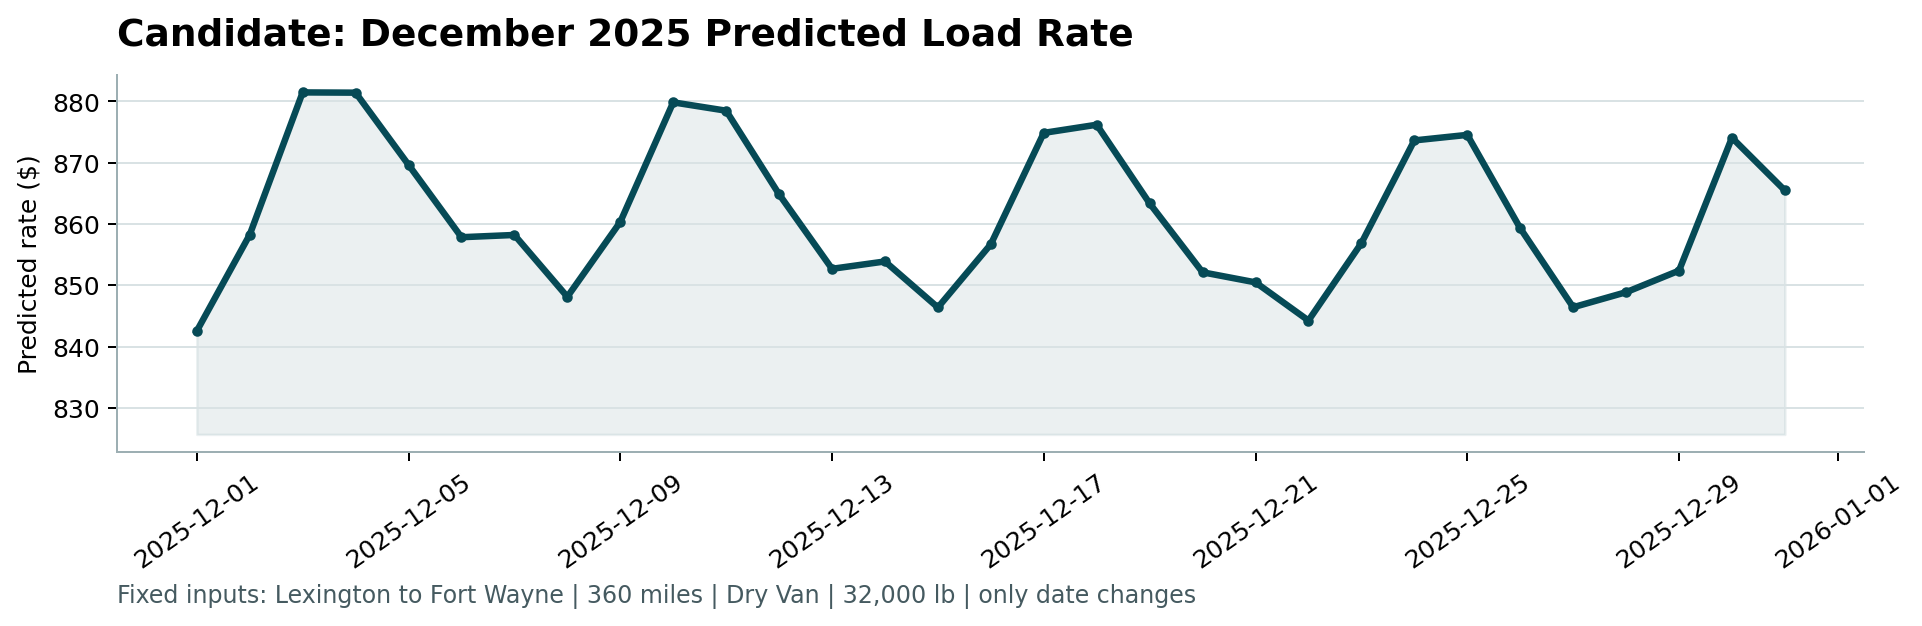

In [99]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/scorer_results/candidate_december.png"
    )
)